# GPU Training Notebook

This notebook allows us to train our model using a GPU.

**Note:** Since the *HubroHub* environment is shared with other students, please remember to stop all GPU processes when your training is complete.

## Install Python Libraries

Start by running the following cell to install required libraries:

In [1]:
!pip install datasets tokenizers

## Imports

Run the following cell to import the necessary files and review the configuration.

In [2]:
from pathlib import Path
from tokenizer import train_tokenizer
from train import train_model
from config import config
from utils import print_config
from matplotlib import pyplot as plt

print_config(config)

Using configuration:
	seed: 0
	dataset: gooaq_subset
	split: train
	device: cuda
	vocab_size: 20000
	min_frequency: 5
	unk_token: [UNK]
	sep_token: [SEP]
	end_token: [END]
	pad_token: [PAD]
	tokenizer_filename: temp/tokenizer.json
	embed_size: 512
	num_heads: 8
	num_layers: 5
	dropout_p: 0.1
	max_len: 128
	model_train_fraction: 1.0
	batch_size: 128
	dataloader_num_workers: 2
	lr: 0.0001
	num_epochs: 5
	model_filename: temp/model.pth
	optimizer_filename: temp/optimizer.pth
****************************************************************************************************


## Training the Tokenizer

Train and save the tokenizer. This might take a few minutes to complete. But you only have to do this once as it will save the tokenizer for later use.

In [3]:
if not Path(config.tokenizer_filename).exists():
  tokenizer = train_tokenizer(config)
else:
  print(f"Tokenizer already exists at {config.tokenizer_filename}")

Tokenizer already exists at temp/tokenizer.json


## Training Your Model

We use the `train_model` function from `train.py`. This will save a model (and optimizer) checkpoint after every 500 batches.

When you have trained your model for around 3-5 epochs, download the model and tokenizer files to keep a copy in your local `temp` folder. You can now use these when doing inference (text generation).

Note that a single epoch might take around 15-30 minutes to complete.

In [4]:
model, train_info = train_model(config)

Using configuration:
	seed: 0
	dataset: gooaq_subset
	split: train
	device: cuda
	vocab_size: 20000
	min_frequency: 5
	unk_token: [UNK]
	sep_token: [SEP]
	end_token: [END]
	pad_token: [PAD]
	tokenizer_filename: temp/tokenizer.json
	embed_size: 512
	num_heads: 8
	num_layers: 5
	dropout_p: 0.1
	max_len: 128
	model_train_fraction: 1.0
	batch_size: 128
	dataloader_num_workers: 2
	lr: 0.0001
	num_epochs: 5
	model_filename: temp/model.pth
	optimizer_filename: temp/optimizer.pth
****************************************************************************************************
Number of parameters in the model: 36,261,920
Loaded dataset of size 859765 with columns ['question', 'answer']


  0%|          | 0/6717 [00:00<?, ?it/s]/opt/conda/lib/python3.13/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
[01 | 05] Loss: 10.0740:   0%|          | 1/6717 [00:14<27:40:51, 14.84s/it]/opt/conda/lib/python3.13/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
[01 | 05] Loss: 0.0054: 100%|█████████▉| 6715/6717 [10:43<00:00, 10.10it/s]/opt/cond


Mean Epoch Cross-Entropy Loss: 0.4010



[02 | 05] Loss: 0.0023: 100%|██████████| 6717/6717 [10:35<00:00, 10.56it/s]


Mean Epoch Cross-Entropy Loss: 0.0032


...


Mean Epoch Cross-Entropy Loss: 0.0016



[04 | 05] Loss: 0.0003: 100%|██████████| 6717/6717 [10:34<00:00, 10.58it/s]


Mean Epoch Cross-Entropy Loss: 0.0011



[05 | 05] Loss: 0.0003: 100%|██████████| 6717/6717 [10:33<00:00, 10.60it/s]



Mean Epoch Cross-Entropy Loss: 0.0009


In [18]:
print(train_info["losses"])

[0.4009774088571787, 0.003188350920188675, 0.0015917594352966554, 0.0011170310209642305, 0.0009087034639733839]


In [17]:
epochs_len = len(train_info["losses"])
epochs = [i for i in range(1,epochs_len+1)]
epochs

[1, 2, 3, 4, 5]

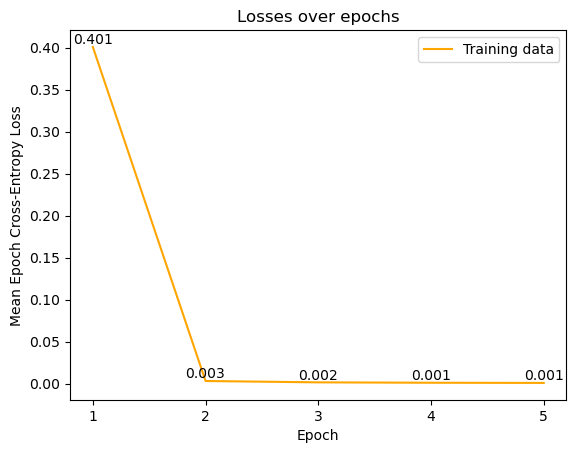

In [22]:
plt.plot(epochs, train_info["losses"], color="orange", label="Training data")

for x, y in zip(epochs, train_info["losses"]):
    plt.text(x, y, f"{y:.3f}", ha='center', va='bottom')

plt.xticks(epochs)
plt.xlabel("Epoch")
plt.ylabel("Mean Epoch Cross-Entropy Loss")
plt.legend()
plt.title("Losses over epochs")
plt.savefig("figs/losses_over_epochs.png")
plt.show()